# Embeddings: convertir texto en números que se pueden comparar

**Bloque 3: embeddings.**
Un modelo de IA no lee palabras: trabaja con números. Un **embedding** convierte un
texto en una lista de números (un vector) de manera que textos con significado
parecido quedan cerca. Es la base de la búsqueda por significado y de RAG.

Al terminar podrás:
1. Representar textos como puntos y medir su parecido con la similitud coseno.
2. Obtener embeddings reales del modelo del `.env` y explicar por qué no se pueden graficar directo.
3. Leer un mapa de calor y un mapa 2D de embeddings, y decir qué muestran y qué no.
4. Buscar las frases más parecidas a una consulta.

| Orden | Actividad |
|---|---|
| 1 | Texto como coordenadas, hecho a mano; ejercicio 1 |
| 2 | Embeddings reales y su tamaño |
| 3 | Mapa de calor: ¿se agrupan por héroe o por tema?; ejercicio 2 |
| 4 | De 3072 dimensiones a un mapa 2D |
| 5 | Búsqueda por significado; ejercicio 3 |
| 6 | Laboratorio real con tu propia frase |

> **Límites de este bloque.** La similitud mide cercanía entre vectores, no verdad
> ni calidad. El mapa 2D es una sombra de miles de dimensiones: sirve para
> orientarse, no para medir. Los vectores reales vienen de un archivo calculado
> una vez con el modelo del `.env`; así todo el grupo ve los mismos resultados
> sin clave ni costo. El laboratorio final calcula frases nuevas en vivo.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

from henry_agents.embeddings_comics import CONSULTAS, FRASES, leer_cache, obtener_embeddings

# Un color por tema y una forma por héroe: el color nunca es la única pista.
COLOR_TEMA = {
    "investigar": "#2a78d6",
    "comunidad": "#eb6834",
    "ciencia": "#1baf7a",
    "otro": "#8a8984",
}
FORMA_HEROE = {"batman": "s", "spiderman": "^", "fantasticos": "D", "ninguno": "o"}
TEMA_DE_TEXTO = {}
for frase in FRASES:
    TEMA_DE_TEXTO[frase["texto"]] = frase["tema"]
print("Librerías listas: math, numpy y matplotlib.")

Librerías listas: math, numpy y matplotlib.


## 1. Texto como coordenadas, hecho a mano

Empecemos con un mapa que inventamos nosotros. Cada frase recibe dos números:
cuánto habla de **misterio** y cuánto de **colaboración**, entre 0 y 1.
Un par de números es un punto en un plano; ya podemos dibujarlo.

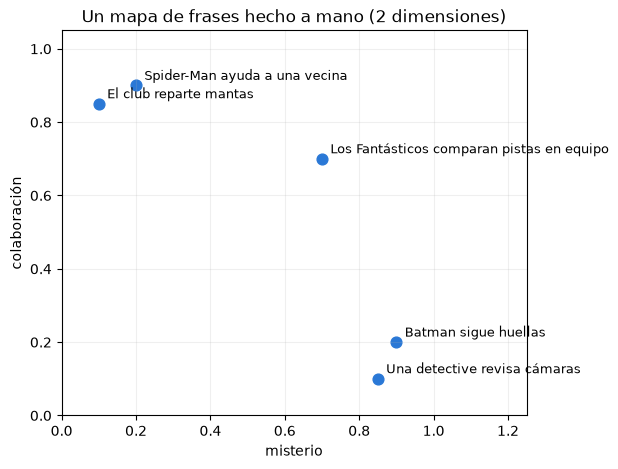

In [2]:
mapa_a_mano = {
    "Batman sigue huellas": (0.9, 0.2),
    "Una detective revisa cámaras": (0.85, 0.1),
    "Spider-Man ayuda a una vecina": (0.2, 0.9),
    "El club reparte mantas": (0.1, 0.85),
    "Los Fantásticos comparan pistas en equipo": (0.7, 0.7),
}

fig, ax = plt.subplots(figsize=(6, 5))
for frase, (misterio, colaboracion) in mapa_a_mano.items():
    ax.scatter(misterio, colaboracion, s=60, color="#2a78d6")
    ax.annotate(frase, (misterio, colaboracion), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_ylim(0, 1.05)
ax.set_xlabel("misterio")
ax.set_ylabel("colaboración")
ax.set_title("Un mapa de frases hecho a mano (2 dimensiones)")
ax.grid(alpha=0.2)
plt.show()

Las frases de investigación quedan abajo a la derecha; las de ayuda, arriba a la
izquierda. Para medir el parecido usamos la **similitud coseno**: compara la
*dirección* de dos flechas que salen del origen.

| Similitud | Significado |
|---|---|
| `1` | Misma dirección: muy parecidas |
| `0` | Perpendiculares: nada en común |

`similitud = (a · b) / (largo de a × largo de b)`

- **Producto punto** `a · b`: multiplica los números por parejas y suma.
  `zip(a, b)` recorre las dos listas de a pares.
- **Largo** de una flecha: raíz cuadrada (`math.sqrt`) de la suma de cada número al cuadrado.

`total += valor` es una forma corta de escribir `total = total + valor`.

In [3]:
a = mapa_a_mano["Batman sigue huellas"]
b = mapa_a_mano["Una detective revisa cámaras"]

producto = 0
for x, y in zip(a, b):
    producto += x * y

suma_cuadrados_a = 0
for x in a:
    suma_cuadrados_a += x * x

suma_cuadrados_b = 0
for y in b:
    suma_cuadrados_b += y * y

largo_a = math.sqrt(suma_cuadrados_a)
largo_b = math.sqrt(suma_cuadrados_b)
print("Producto punto:", round(producto, 3))
print("Largos:", round(largo_a, 3), round(largo_b, 3))
print("Similitud Batman–detective:", round(producto / (largo_a * largo_b), 3))

Producto punto: 0.785
Largos: 0.922 0.856
Similitud Batman–detective: 0.995


### Ejercicio 1 · La similitud coseno como función

Convierte el cálculo anterior en una función que reciba dos vectores de cualquier
largo. La usaremos después con vectores de 3072 números.

**Predice:** ¿qué similitud tendrá "Batman sigue huellas" con "Spider-Man ayuda a
una vecina": cerca de 1 o cerca de 0?

**Pista:** copia el cálculo de la celda anterior dentro de la función, con una
sangría más, y devuelve el cociente con `return`.

In [4]:
def similitud_practica(a, b):
    # Calcula producto, largo_a y largo_b, y devuelve la similitud.
    return -1.0  # Valor provisional: reemplázalo por el cálculo.


print("Misma dirección da 1:", round(similitud_practica((1, 0), (3, 0)), 3) == 1.0)
print("Perpendiculares dan 0:", round(similitud_practica((1, 0), (0, 2)), 3) == 0.0)
print("A 45 grados da 0.707:", round(similitud_practica((1, 0), (1, 1)), 3) == 0.707)
print("Batman–Spider-Man:", round(similitud_practica(
    mapa_a_mano["Batman sigue huellas"], mapa_a_mano["Spider-Man ayuda a una vecina"]), 3))

Misma dirección da 1: False
Perpendiculares dan 0: False
A 45 grados da 0.707: False
Batman–Spider-Man: -1.0


<details>
<summary>Solución del ejercicio 1</summary>

```python
def similitud_practica(a, b):
    producto = 0
    for x, y in zip(a, b):
        producto += x * y
    suma_cuadrados_a = 0
    for x in a:
        suma_cuadrados_a += x * x
    suma_cuadrados_b = 0
    for y in b:
        suma_cuadrados_b += y * y
    return producto / (math.sqrt(suma_cuadrados_a) * math.sqrt(suma_cuadrados_b))
```

Batman–Spider-Man da cerca de 0.4: comparten poco en este mapa. Fíjate que la
función no depende de que haya dos números; funciona con cualquier largo.
</details>

**Prueba libre:** agrega tu frase a `mapa_a_mano` con dos coordenadas, reejecuta el
gráfico y explica a qué frases debería parecerse.

## 2. Embeddings reales: nadie elige los ejes

En el mapa a mano **nosotros** decidimos los ejes. Un modelo de embeddings aprende
sus propios ejes leyendo enormes cantidades de texto. El resultado es una lista
mucho más larga, y ningún número por separado significa "misterio" o "ciencia".

Trabajaremos con 14 frases: tres temas con tres héroes, tres frases sin héroe y
dos frases fuera del tema de cómics. Las etiquetas `heroe` y `tema` las pusimos
nosotros para colorear; el modelo solo recibe el texto.

In [5]:
cache = leer_cache()
# Lista por comprensión: equivale a un for que hace append de cada texto.
textos = [frase["texto"] for frase in FRASES]
vectores = obtener_embeddings(textos, mode="offline")

print("Modelo que calculó los vectores:", cache["modelo"], "el", cache["generado_el"])
print("Cantidad de frases:", len(vectores))
print("Números por frase:", len(vectores[0]))
print("Primeros cinco números de la frase 0:", vectores[0][:5])

Modelo que calculó los vectores: text-embedding-3-large el 2026-10-07
Cantidad de frases: 14
Números por frase: 3072
Primeros cinco números de la frase 0: [0.01596, 0.00035, 0.00091, -0.00829, 0.01753]


Cada frase es ahora una lista de 3072 números. No podemos dibujar 3072 ejes,
pero sí podemos **comparar**: la similitud coseno funciona igual con 2 números
que con 3072. Tu función del ejercicio 1 sirve tal cual.

Para trabajar con muchas listas usamos `numpy`: `np.array` convierte la lista de
listas en una tabla de 14 filas × 3072 columnas. Estos vectores vienen con largo
1, así que la similitud coseno es simplemente el producto punto; `@` calcula todos
los productos de una vez.

In [6]:
matriz = np.array(vectores)
print("Forma de la tabla:", matriz.shape)
print("Largo de cada vector:", np.linalg.norm(matriz, axis=1).round(3))

similitudes = matriz @ matriz.T
print("Similitud frase 0 con frase 9 (numpy):", round(float(similitudes[0, 9]), 3))
print("Tu función da lo mismo:", round(similitud_practica(vectores[0], vectores[9]), 3)
      == round(float(similitudes[0, 9]), 3))

Forma de la tabla: (14, 3072)
Largo de cada vector: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Similitud frase 0 con frase 9 (numpy): 0.478
Tu función da lo mismo: False


## 3. Mapa de calor: ¿se agrupan por héroe o por tema?

**Predice antes de ejecutar:** "Batman sigue huellas" se parecerá más a
"Batman calibra un sensor" (mismo héroe, otro tema) o a "Spider-Man interroga
a los testigos" (otro héroe, mismo tema)?

El mapa de calor muestra la similitud de cada frase con todas las demás.
Más oscuro significa más parecido. La diagonal vale 1: cada frase consigo misma.

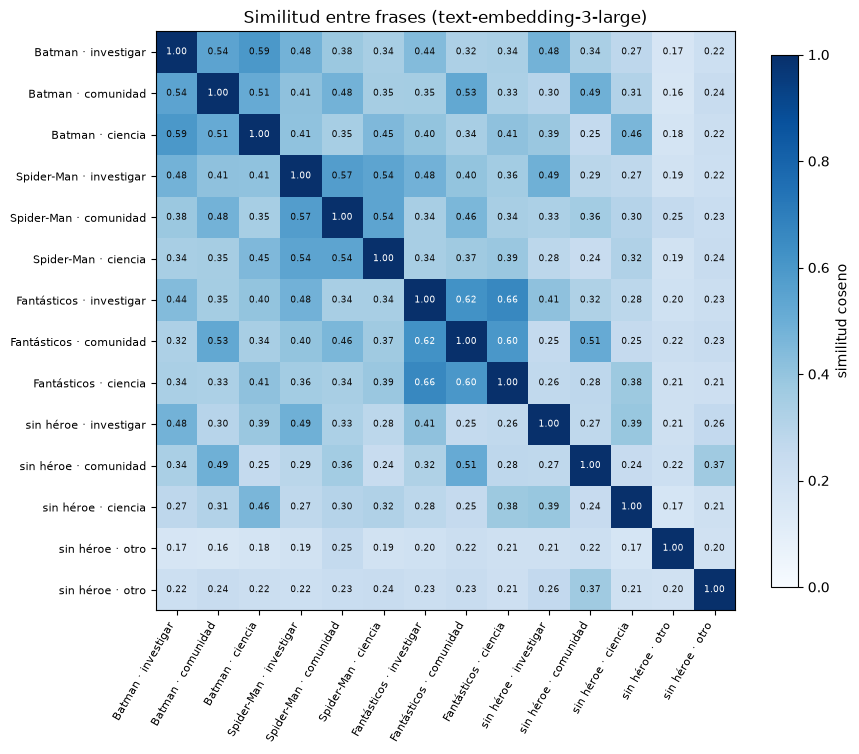

In [7]:
NOMBRE_CORTO = {"batman": "Batman", "spiderman": "Spider-Man", "fantasticos": "Fantásticos",
                "ninguno": "sin héroe"}
etiquetas = [f"{NOMBRE_CORTO[f['heroe']]} · {f['tema']}" for f in FRASES]

fig, ax = plt.subplots(figsize=(9, 8))
imagen = ax.imshow(similitudes, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(etiquetas)), etiquetas, fontsize=8)
for fila in range(len(etiquetas)):
    for columna in range(len(etiquetas)):
        valor = similitudes[fila, columna]
        ax.text(columna, fila, f"{valor:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if valor > 0.6 else "#0b0b0b")
fig.colorbar(imagen, ax=ax, label="similitud coseno", shrink=0.8)
ax.set_title(f"Similitud entre frases ({cache['modelo']})")
plt.tight_layout()
plt.show()

Observa tres cosas: los bloques más oscuros, la fila de las frases fuera del tema
(receta y fútbol) y si los cuadros oscuros siguen al héroe o al tema. Una mirada
no alcanza para decidirlo: hagamos la cuenta.

### Ejercicio 2 · Medir en vez de adivinar

Recorre todas las parejas de frases distintas (`i < j`) y separa sus similitudes
en dos listas:

- `mismo_heroe`: mismo héroe (que no sea `"ninguno"`) y **distinto** tema.
- `mismo_tema`: mismo tema (que no sea `"otro"`) y **distinto** héroe.

Luego compara los promedios. **Pista:** dos `for` anidados con `range(len(FRASES))`,
`if j <= i: continue` para no repetir parejas, y `similitudes[i, j]` para el valor.

In [8]:
mismo_heroe = []
mismo_tema = []
# Completa aquí los dos ciclos y las dos condiciones.

print("Parejas mismo héroe (deben ser 9):", len(mismo_heroe))
print("Parejas mismo tema (deben ser 18):", len(mismo_tema))
if mismo_heroe and mismo_tema:
    print("Promedio mismo héroe, otro tema:", round(float(np.mean(mismo_heroe)), 3))
    print("Promedio mismo tema, otro héroe:", round(float(np.mean(mismo_tema)), 3))

Parejas mismo héroe (deben ser 9): 0
Parejas mismo tema (deben ser 18): 0


<details>
<summary>Solución del ejercicio 2</summary>

```python
mismo_heroe = []
mismo_tema = []
for i in range(len(FRASES)):
    for j in range(len(FRASES)):
        if j <= i:
            continue
        a, b = FRASES[i], FRASES[j]
        if a["heroe"] == b["heroe"] and a["heroe"] != "ninguno" and a["tema"] != b["tema"]:
            mismo_heroe.append(similitudes[i, j])
        if a["tema"] == b["tema"] and a["tema"] != "otro" and a["heroe"] != b["heroe"]:
            mismo_tema.append(similitudes[i, j])
```

Con los vectores del archivo, compartir héroe da cerca de 0.58 y compartir tema
cerca de 0.45: **el nombre del héroe pesa más que el tema**. El embedding resume
todo el texto, nombres incluidos, no solo la idea que a nosotros nos interesa.
Eso importa al buscar: lo veremos en la sección 5.
</details>

## 4. De 3072 dimensiones a un mapa 2D

Para dibujar necesitamos bajar a dos números por frase. Usamos **PCA**: busca las
dos direcciones en las que las frases más se diferencian y proyecta cada frase
sobre ellas, como la sombra de un objeto 3D sobre una pared. No necesitas la
matemática: `np.linalg.svd` encuentra esas direcciones.

Calcularemos también qué porción de la variación total conserva la sombra.

In [9]:
centro = matriz.mean(axis=0)
_, valores_singulares, direcciones = np.linalg.svd(matriz - centro, full_matrices=False)
coordenadas = (matriz - centro) @ direcciones[:2].T
conservado = (valores_singulares[:2] ** 2).sum() / (valores_singulares ** 2).sum()

vectores_consultas = np.array(obtener_embeddings(CONSULTAS, mode="offline"))
coordenadas_consultas = (vectores_consultas - centro) @ direcciones[:2].T

print("Coordenadas 2D:", coordenadas.shape)
print(f"Variación conservada en 2D: {conservado:.0%}")

Coordenadas 2D: (14, 2)
Variación conservada en 2D: 27%


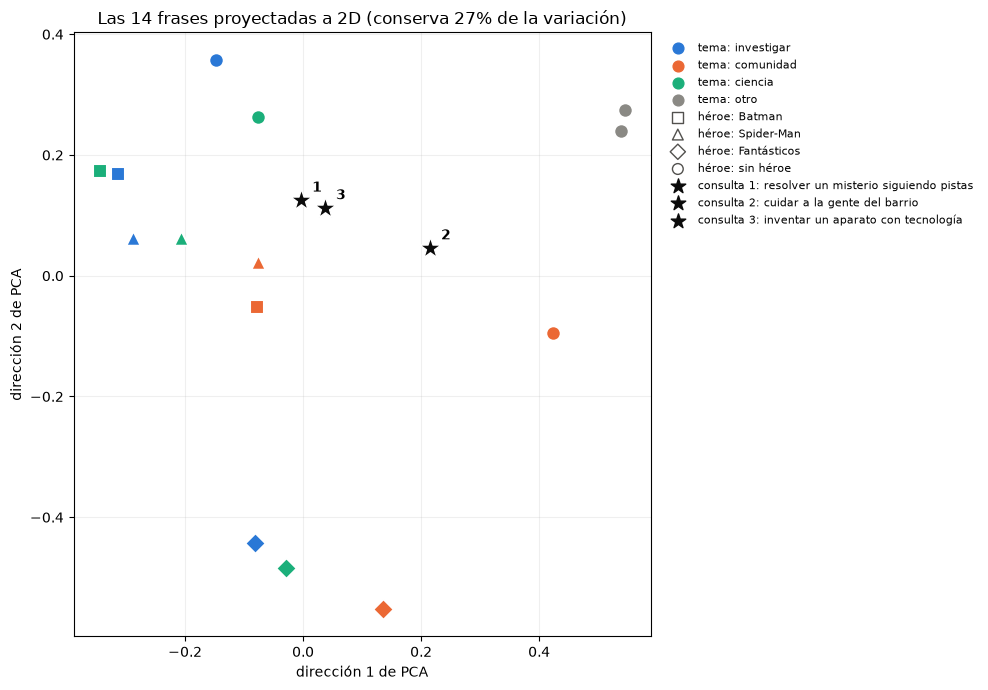

In [10]:
# El color dice el tema y la forma dice el héroe; las consultas son estrellas numeradas.
fig, ax = plt.subplots(figsize=(10, 7))
for frase, (x, y) in zip(FRASES, coordenadas):
    ax.scatter(x, y, s=110, color=COLOR_TEMA[frase["tema"]], marker=FORMA_HEROE[frase["heroe"]],
               edgecolors="white", linewidths=1.5, zorder=3)
for numero, (x, y) in enumerate(coordenadas_consultas, start=1):
    ax.scatter(x, y, s=260, marker="*", color="#0b0b0b", edgecolors="white", zorder=4)
    ax.annotate(str(numero), (x, y), xytext=(8, 6), textcoords="offset points",
                fontsize=10, fontweight="bold")

for tema, color in COLOR_TEMA.items():
    ax.scatter([], [], color=color, marker="o", s=60, label=f"tema: {tema}")
for heroe, forma in FORMA_HEROE.items():
    ax.scatter([], [], facecolors="none", edgecolors="#52514e", marker=forma, s=60,
               label=f"héroe: {NOMBRE_CORTO[heroe]}")
for numero, consulta in enumerate(CONSULTAS, start=1):
    ax.scatter([], [], color="#0b0b0b", marker="*", s=120, label=f"consulta {numero}: {consulta}")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.set_xlabel("dirección 1 de PCA")
ax.set_ylabel("dirección 2 de PCA")
ax.set_title(f"Las 14 frases proyectadas a 2D (conserva {conservado:.0%} de la variación)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Busca en el mapa: ¿dónde quedan los rombos de los Cuatro Fantásticos? ¿Y los dos
puntos grises de la receta y el fútbol? ¿Coincide con lo que mediste en el ejercicio 2?

Mira ahora las estrellas: las consultas quedan cerca del centro, lejos de sus
frases. ¿La búsqueda falla? Lo comprobaremos en la siguiente sección. Si el mapa y
las similitudes no coinciden, cree a las similitudes: la sombra 2D conserva solo
una parte de la información.

## 5. Búsqueda por significado

Buscar es comparar: calculamos el vector de la consulta, medimos su similitud con
cada frase y nos quedamos con las más altas. Las tres consultas ya calculadas
**no nombran a ningún héroe**.

### Ejercicio 3 · Las k frases más parecidas

Completa `buscar_practica`: arma una lista de parejas `(similitud, texto)` con un
ciclo, ordénala de mayor a menor y devuelve las primeras `k`.

**Pista:** `sorted(parejas, reverse=True)[:k]` ordena tuplas por su primer valor.
Usa `float(...)` para guardar la similitud como número de Python.

In [11]:
def buscar_practica(vector_consulta, k=3):
    parejas = []
    # Recorre FRASES junto con las filas de `matriz` y calcula cada similitud.
    return parejas


consulta_elegida = 0  # Cambia a 1 o 2 para probar las otras consultas.
resultados = buscar_practica(vectores_consultas[consulta_elegida], k=4)
print("Consulta:", CONSULTAS[consulta_elegida])
for similitud, texto in resultados:
    print(f"  {similitud:.3f}  {texto}")
temas_encontrados = []
for _, texto in resultados:
    temas_encontrados.append(TEMA_DE_TEXTO[texto])
print("Devuelve 4 resultados:", len(resultados) == 4)
print("Ordenados de mayor a menor:", len(resultados) > 1 and resultados == sorted(resultados, reverse=True))
print("Temas encontrados:", temas_encontrados)

Consulta: resolver un misterio siguiendo pistas
Devuelve 4 resultados: False
Ordenados de mayor a menor: False
Temas encontrados: []


<details>
<summary>Solución del ejercicio 3</summary>

```python
def buscar_practica(vector_consulta, k=3):
    parejas = []
    for frase, vector in zip(FRASES, matriz):
        similitud = float(np.dot(vector_consulta, vector))
        parejas.append((similitud, frase["texto"]))
    return sorted(parejas, reverse=True)[:k]
```

Con las tres consultas, las cuatro primeras frases son las cuatro del tema
correcto, con y sin héroe. Como la consulta no nombra a nadie, ahora el tema
decide: el ejercicio 2 y este resultado son coherentes. En el mapa 2D las
estrellas parecían lejos de sus frases; en 3072 dimensiones están cerca.
</details>

El gráfico de barras muestra la similitud de una consulta con **todas** las frases.
Observa la distancia entre las primeras y el resto: una búsqueda real necesita
decidir cuántos resultados vale la pena usar.

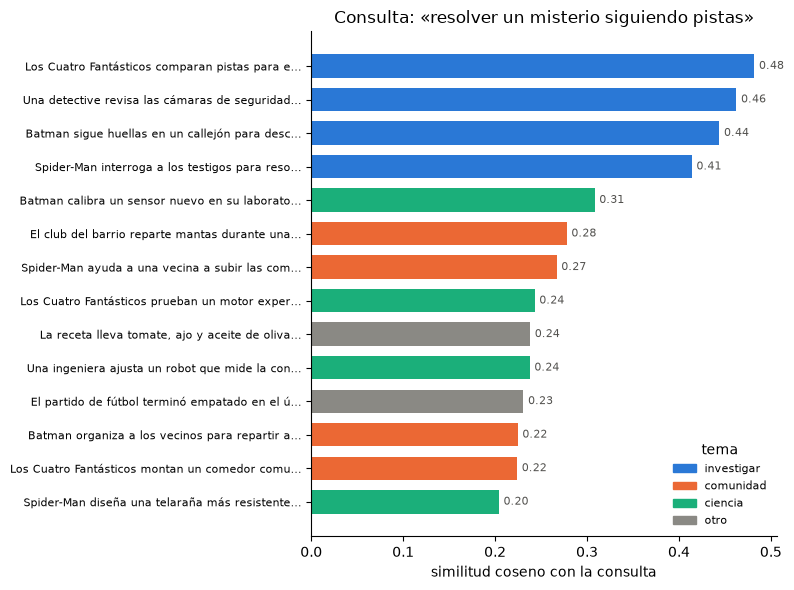

In [12]:
similitud_consulta = matriz @ vectores_consultas[consulta_elegida]
orden = np.argsort(similitud_consulta)

fig, ax = plt.subplots(figsize=(8, 6))
for fila, indice in enumerate(orden):
    frase = FRASES[indice]
    ax.barh(fila, similitud_consulta[indice], color=COLOR_TEMA[frase["tema"]], height=0.7)
    ax.text(similitud_consulta[indice] + 0.005, fila, f"{similitud_consulta[indice]:.2f}",
            va="center", fontsize=8, color="#52514e")
ax.set_yticks(range(len(orden)), [FRASES[i]["texto"][:45] + "…" for i in orden], fontsize=8)
leyenda = []
for tema, color in COLOR_TEMA.items():
    leyenda.append(Patch(color=color, label=tema))
ax.legend(handles=leyenda, title="tema", fontsize=8, loc="lower right", frameon=False)
ax.set_xlabel("similitud coseno con la consulta")
ax.set_title(f"Consulta: «{CONSULTAS[consulta_elegida]}»")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Laboratorio real: tu propia frase

Las secciones anteriores usaron vectores guardados. Aquí calculas frases nuevas con
el modelo de `OPENAI_EMBEDDING_MODEL` del `.env`. Necesitas `OPENAI_API_KEY`;
reinicia el kernel si acabas de completarla. No pegues la clave en una celda.

Para comparar vectores del mismo modelo, la celda vuelve a calcular las 14 frases
junto con la tuya: es una sola llamada con 15 textos cortos, de costo muy bajo
(consulta el precio vigente en [modelos](../../docs/MODELOS.md)). Reejecutar
vuelve a consumir.

In [13]:
EJECUTAR_EMBEDDINGS_REALES = False
mi_frase = "Batman y Spider-Man arreglan juntos el semáforo del barrio."

if EJECUTAR_EMBEDDINGS_REALES:
    vectores_vivos = np.array(obtener_embeddings([mi_frase, *textos], mode="live"))
    mi_vector, frases_vivas = vectores_vivos[0], vectores_vivos[1:]
    parecidos = sorted(zip(frases_vivas @ mi_vector, textos), reverse=True)[:3]
    print("Tu frase:", mi_frase)
    print("Dimensiones:", len(mi_vector))
    for similitud, texto in parecidos:
        print(f"  {similitud:.3f}  {texto}")
else:
    print("Laboratorio real pendiente: bandera desactivada. No se llamó al modelo.")

Laboratorio real pendiente: bandera desactivada. No se llamó al modelo.


**Experimentos sugeridos:** escribe la misma idea sin nombrar al héroe; escribe una
frase en inglés; escribe una frase con las mismas palabras y significado opuesto.
Anota qué cambió en las tres más parecidas y si coincide con tu predicción.

## 7. Salida del bloque

En parejas, respondan con evidencia de este notebook:

1. ¿Por qué la función del ejercicio 1 sirve igual con 2 y con 3072 números?
2. ¿Las frases se agruparon por héroe o por tema? ¿Qué cifra lo muestra?
3. ¿Por qué la búsqueda sin nombre de héroe encontró las frases del tema correcto?
4. ¿Qué información pierde el mapa 2D y cómo lo comprobaron?

En el próximo bloque las fuentes del guion se eligen **por héroe**, con una regla
escrita en Python. Con lo que viste aquí podrían elegirse **por significado**: esa
es la idea central de RAG, que se estudia en la ruta avanzada.
Continúa con [03 · Modelos y revisión](03_modelos_y_revision.ipynb).